### 소화/대사계 (ATC 코드 A계열)
- 변비약 + 완하제

In [1]:
!pip install scipy -q
!apt-get install -y fonts-nanum -q > /dev/null

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, chi2_contingency

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드 및 완하제 그룹 정의
df = pd.read_csv('/content/FDA_adverse_events_final.csv')
N_total = len(df)

ingredients = {
    '마크로골(PEG)': ['macrogol', 'polyethylene glycol', 'peg 3350', 'miralax'],
    '비사코딜': ['bisacodyl'], '센나': ['senna', 'sennoside'],
    '도큐세이트': ['docusate'], '차전자피': ['psyllium'],
}
sd = df['suspect_drug'].astype(str).str.lower()
all_lax_mask = pd.Series(False, index=df.index)
for keys in ingredients.values():
    for k in keys:
        all_lax_mask = all_lax_mask | sd.str.contains(k, na=False)

# 안구용(인공눈물/SYSTANE) 제품 제외
df['drug_route_num'] = pd.to_numeric(df['drug_route'], errors='coerce')
bn = df['brand_name'].astype(str).str.lower()
not_laxative_mask = bn.str.contains('systane', na=False) | (df['drug_route_num'] == 47)
corrected_mask = all_lax_mask & (~not_laxative_mask)
lax_mask = corrected_mask
n_drug = corrected_mask.sum()
n_other = N_total - n_drug

lax = df[corrected_mask].copy()
lax['receive_date'] = pd.to_datetime(lax['receive_date'])
lax['year'] = lax['receive_date'].dt.year
sev_cols = ['is_fatal', 'is_hospitalized', 'is_life_threat', 'is_disabling']
lax['any_severe'] = lax[sev_cols].any(axis=1)
lax['reaction_list'] = lax['reactions'].astype(str).str.split(';').apply(
    lambda l: [x.strip() for x in l if x.strip() and x.strip().lower() != 'unknown'])

print(f"보정 전 완하제군: {all_lax_mask.sum()}건 -> 보정 후: {n_drug}건")

# PRR/ROR 계산 함수
def calc_prr_ror(target_mask, df_all, min_count=3, exclude_terms=None):
    n_d = target_mask.sum()
    n_o = len(df_all) - n_d
    rl = (df_all['reactions'].astype(str).str.split(';')
          .apply(lambda l: [x.strip() for x in l if x.strip() and x.strip().lower() != 'unknown']))
    tmp = pd.DataFrame({'report_id': df_all['report_id'], 'is_target': target_mask.values, 'reaction_list': rl.values})
    ex = tmp.explode('reaction_list').dropna(subset=['reaction_list'])
    ex = ex.drop_duplicates(subset=['report_id', 'reaction_list'])
    if exclude_terms:
        ex = ex[~ex['reaction_list'].isin(exclude_terms)]
    res = []
    for reaction, grp in ex.groupby('reaction_list'):
        a = grp['is_target'].sum(); rt = len(grp); c = rt - a; b = n_d - a; d = n_o - c
        if a < min_count or n_d == 0:
            continue
        if min(a, b, c, d) == 0:
            a_, b_, c_, d_ = a+.5, b+.5, c+.5, d+.5
        else:
            a_, b_, c_, d_ = a, b, c, d
        prr = (a_/(a_+b_)) / (c_/(c_+d_))
        ror = (a_*d_) / (b_*c_)
        se = np.sqrt(1/a_ + 1/b_ + 1/c_ + 1/d_)
        res.append({'reaction': reaction, 'a': a, 'PRR': round(prr, 2), 'ROR': round(ror, 2),
                     'ROR_CI_low': round(np.exp(np.log(ror)-1.96*se), 2)})
    if not res:
        return pd.DataFrame(columns=['reaction', 'a', 'PRR', 'ROR', 'ROR_CI_low'])
    return pd.DataFrame(res).sort_values('PRR', ascending=False)

res_all = calc_prr_ror(corrected_mask, df)

med_err_terms = [
    'Product prescribing issue', 'Incorrect product administration duration', 'Product solubility abnormal',
    'Circumstance or information capable of leading to medication error', 'Poor quality drug administered',
    'Product taste abnormal', 'Product odour abnormal', 'Incorrect dosage administered', 'Underdose',
    'Extra dose administered', 'Inappropriate schedule of drug administration',
    'Wrong technique in product usage process', 'Incorrect dose administered',
    'Product use in unapproved indication', 'Expired product administered', 'Off label use',
    'Product quality issue', 'Product use issue', 'Incorrect drug administration duration',
    'Therapeutic product effect decreased', 'Drug effect decreased', 'Drug ineffective',
]
res_clean = calc_prr_ror(corrected_mask, df, exclude_terms=med_err_terms)

보정 전 완하제군: 165건 -> 보정 후: 142건


In [2]:
# 보정 결과 확인 (안구용 제품 제외 전/후, 성분별 재확인)
print(f"보정 전 완하제군: {all_lax_mask.sum()}건")
print(f"제외된 안구용 제품: {(all_lax_mask & not_laxative_mask).sum()}건")
print(f"보정 후 완하제군: {corrected_mask.sum()}건")

for name, keys in ingredients.items():
    m = pd.Series(False, index=df.index)
    for k in keys:
        m = m | sd.str.contains(k, na=False)
    m_corrected = m & (~not_laxative_mask)
    print(f"  {name}: {m.sum()}건 -> 보정 후 {m_corrected.sum()}건")

보정 전 완하제군: 165건
제외된 안구용 제품: 23건
보정 후 완하제군: 142건
  마크로골(PEG): 134건 -> 보정 후 111건
  비사코딜: 11건 -> 보정 후 11건
  센나: 12건 -> 보정 후 12건
  도큐세이트: 9건 -> 보정 후 9건
  차전자피: 2건 -> 보정 후 2건


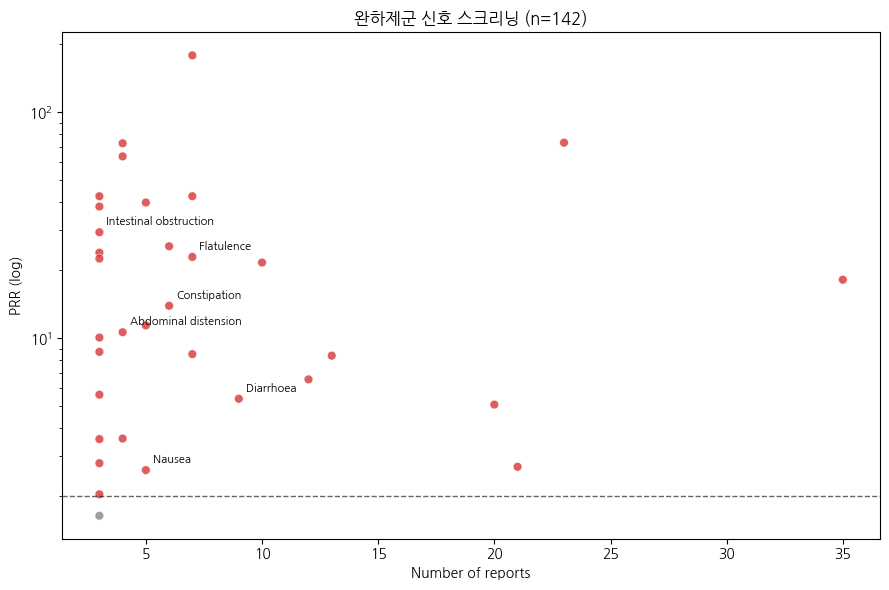

In [3]:
# 볼케이노 플롯
fig, ax = plt.subplots(figsize=(9, 6))
colors = np.where(res_all['PRR'] >= 2, '#d62728', '#7f7f7f')
ax.scatter(res_all['a'], res_all['PRR'], s=40, c=colors, alpha=0.75, edgecolors='white', linewidths=0.5)
ax.set_yscale('log'); ax.axhline(2, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Number of reports'); ax.set_ylabel('PRR (log)')
ax.set_title(f'완하제군 신호 스크리닝 (n={n_drug})')
clinical = ['Constipation', 'Intestinal obstruction', 'Diarrhoea', 'Flatulence', 'Abdominal distension', 'Nausea']
for _, r in res_all.iterrows():
    if r['reaction'] in clinical:
        ax.annotate(r['reaction'], (r['a'], r['PRR']), fontsize=8, xytext=(5, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

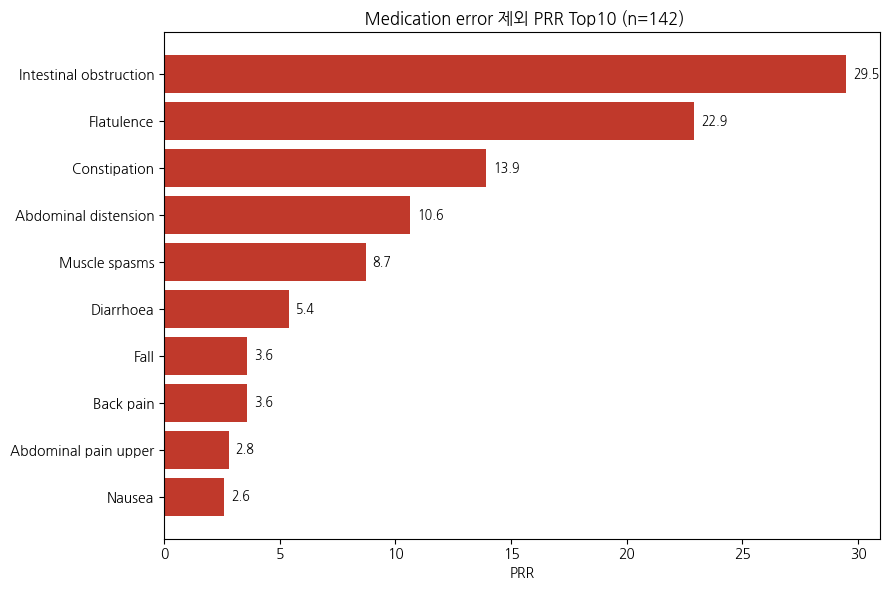

In [4]:
# Medication error 제외 PRR Top10
top10c = res_clean.head(10)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top10c['reaction'][::-1], top10c['PRR'][::-1], color='#c0392b')
for i, v in enumerate(top10c['PRR'][::-1]):
    ax.text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=9)
ax.set_xlabel('PRR'); ax.set_title(f' Medication error 제외 PRR Top10 (n={n_drug})')
plt.tight_layout()
plt.show()

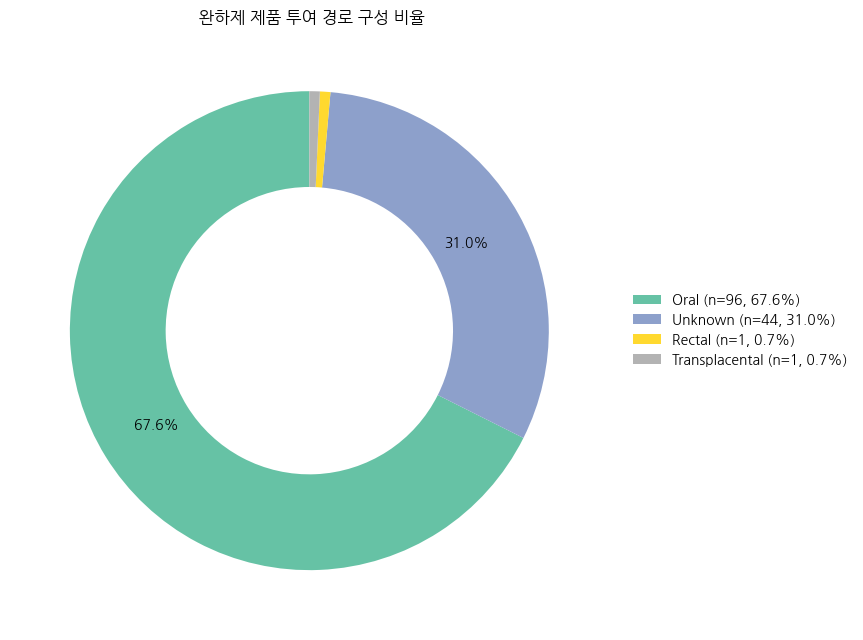

In [5]:
# route 비율 (도넛 차트)
route_code_map = {47: 'Ophthalmic', 48: 'Oral', 54: 'Rectal', 64: 'Transplacental', 65: 'Unknown'}
lax['drug_route_label'] = lax['drug_route_num'].map(route_code_map)
lax.loc[lax['drug_route'].astype(str).str.lower() == 'unknown', 'drug_route_label'] = 'Unknown'
lax['drug_route_label'] = lax['drug_route_label'].fillna('Unknown')
rc = lax['drug_route_label'].value_counts()
fig, ax = plt.subplots(figsize=(9, 6.5))
colors2 = plt.cm.Set2(np.linspace(0, 1, len(rc)))
wedges, _, at = ax.pie(rc.values, autopct=lambda p: f'{p:.1f}%' if p >= 3 else '', startangle=90,
                       colors=colors2, pctdistance=0.75, wedgeprops=dict(width=0.4))
legend_labels = [f'{n} (n={v}, {v/len(lax)*100:.1f}%)' for n, v in rc.items()]
ax.legend(wedges, legend_labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=False)
ax.set_title(f' 완하제 제품 투여 경로 구성 비율')
plt.tight_layout()
plt.show()

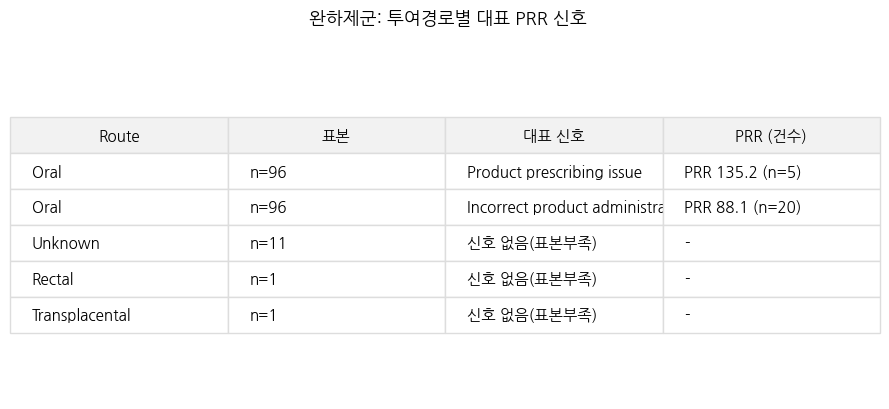

In [6]:
# 투여경로별 대표 PRR 신호 표
routes = [(48, 'Oral'), (65, 'Unknown'), (54, 'Rectal'), (64, 'Transplacental')]
rows = []
for code, name in routes:
    sub_mask = corrected_mask & (df['drug_route_num'] == code)
    n = sub_mask.sum()
    res = calc_prr_ror(sub_mask, df)
    if len(res) == 0:
        rows.append([name, f'n={n}', '신호 없음(표본부족)', '-'])
        continue
    top2 = res.head(2)
    for _, r in top2.iterrows():
        rows.append([name, f'n={n}', r['reaction'], f"PRR {r['PRR']:.1f} (n={r['a']})"])

fig, ax = plt.subplots(figsize=(9, len(rows)*0.6 + 1.2))
ax.axis('off')
col_labels = ['Route', '표본', '대표 신호', 'PRR (건수)']
table = ax.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.0)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#dddddd')
    if r == 0:
        cell.set_text_props(weight='bold'); cell.set_facecolor('#f2f2f2')
    else:
        cell.set_facecolor('white')
plt.title(' 완하제군: 투여경로별 대표 PRR 신호', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

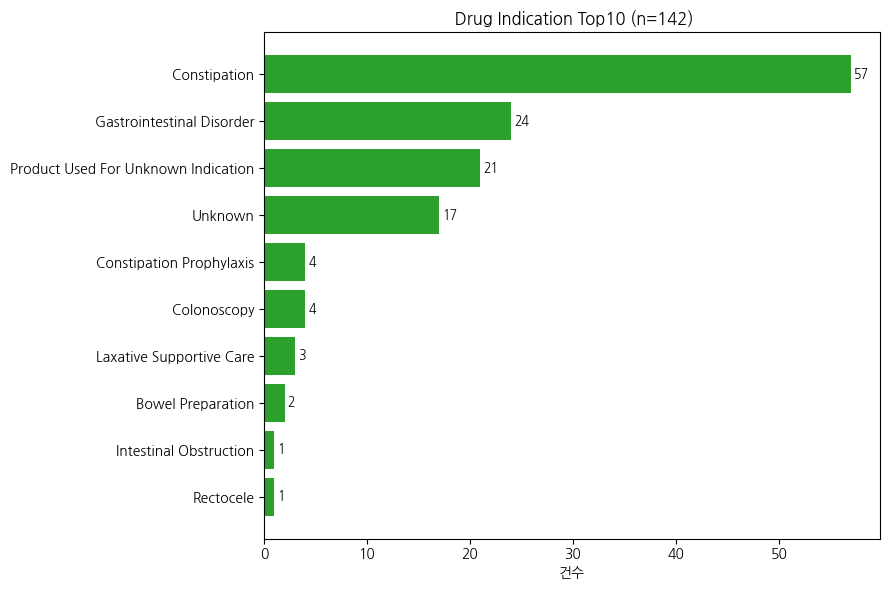

In [7]:
# drug_indication Top10
ind = lax['drug_indication'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(ind.index[::-1], ind.values[::-1], color='#2ca02c')
for i, v in enumerate(ind.values[::-1]):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)
ax.set_xlabel('건수'); ax.set_title(f' Drug Indication Top10 (n={len(lax)})')
plt.tight_layout()
plt.show()

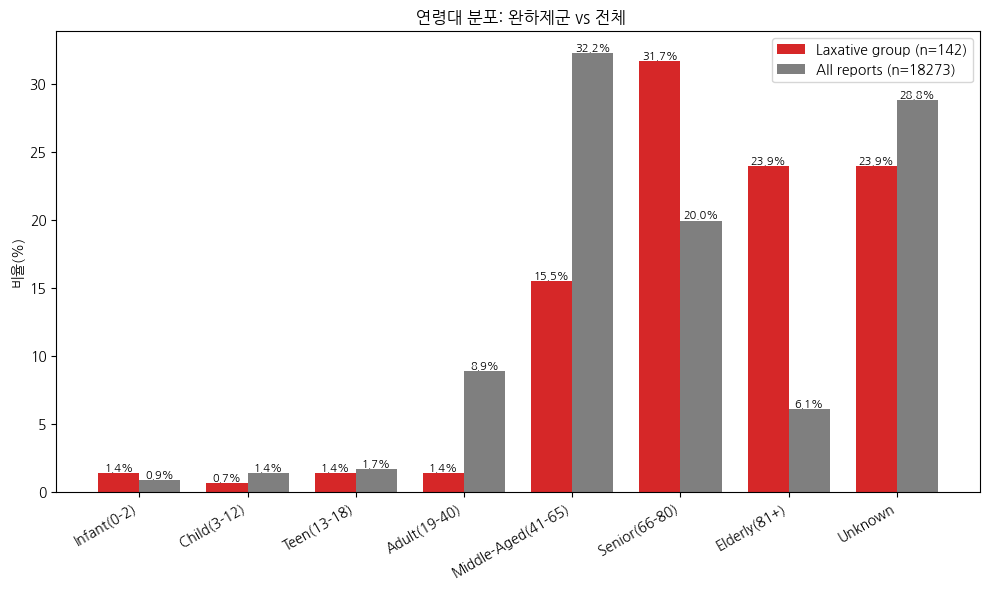

In [8]:
# 연령 분포 비교 (완하제군 vs 전체)
order = ['Infant(0-2)', 'Child(3-12)', 'Teen(13-18)', 'Adult(19-40)',
         'Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)', 'Unknown']
lax_dist = lax['age_group'].value_counts(normalize=True).reindex(order).fillna(0) * 100
all_dist = df['age_group'].value_counts(normalize=True).reindex(order).fillna(0) * 100
x = np.arange(len(order)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - w/2, lax_dist.values, w, label=f'Laxative group (n={n_drug})', color='#d62728')
b2 = ax.bar(x + w/2, all_dist.values, w, label=f'All reports (n={N_total})', color='#7f7f7f')
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.annotate(f'{h:.1f}%', (bar.get_x() + bar.get_width()/2, h), ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30, ha='right')
ax.set_ylabel('비율(%)'); ax.set_title(' 연령대 분포: 완하제군 vs 전체')
ax.legend(); plt.tight_layout()
plt.show()

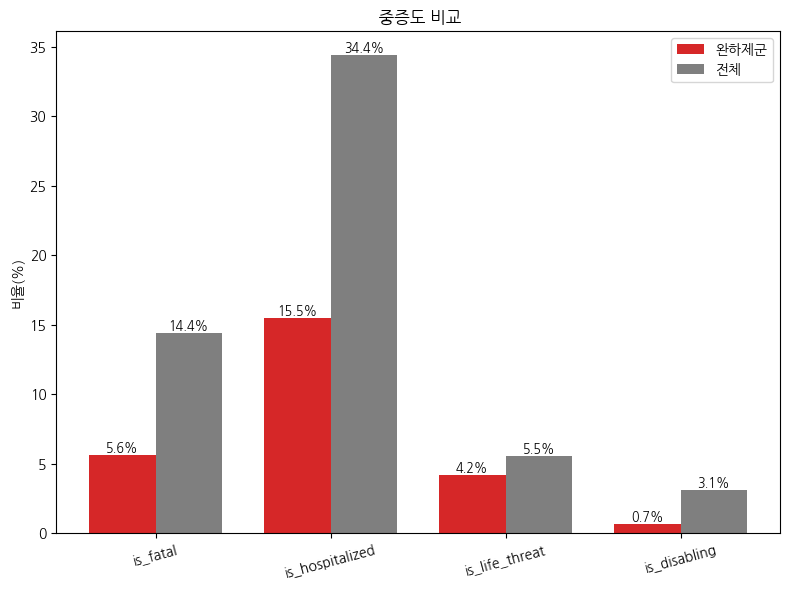

In [9]:
# 중증도 비교
comp = pd.DataFrame({'완하제군(%)': [lax[c].mean()*100 for c in sev_cols],
                      '전체(%)': [df[c].mean()*100 for c in sev_cols]}, index=sev_cols)
x = np.arange(len(sev_cols))
fig, ax = plt.subplots(figsize=(8, 6))
b1 = ax.bar(x - 0.19, comp['완하제군(%)'], 0.38, label='완하제군', color='#d62728')
b2 = ax.bar(x + 0.19, comp['전체(%)'], 0.38, label='전체', color='#7f7f7f')
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}%', (bar.get_x() + bar.get_width()/2, h), ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(sev_cols, rotation=15)
ax.set_ylabel('비율(%)'); ax.set_title(' 중증도 비교'); ax.legend()
plt.tight_layout()
plt.show()

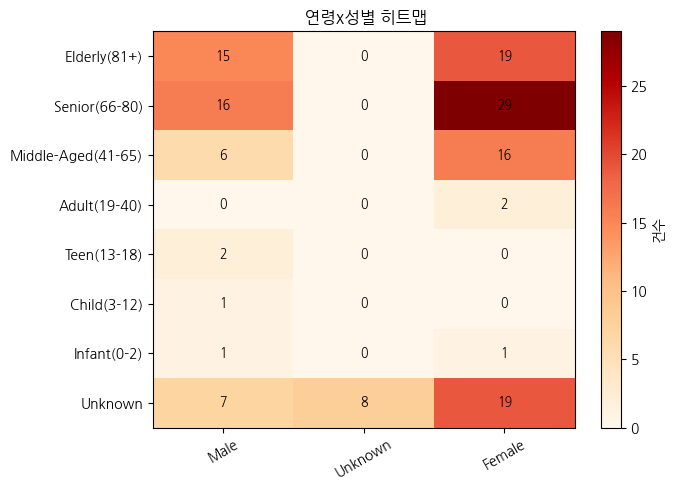

In [10]:
# 연령 x 성별 히트맵 (연령 내림차순, 여성 오른쪽)
age_order_desc = ['Elderly(81+)', 'Senior(66-80)', 'Middle-Aged(41-65)', 'Adult(19-40)',
                   'Teen(13-18)', 'Child(3-12)', 'Infant(0-2)', 'Unknown']
sex_order = ['Male', 'Unknown', 'Female']
ct = lax.groupby(['age_group', 'patient_sex']).size().unstack(fill_value=0).reindex(
    index=age_order_desc, columns=sex_order, fill_value=0)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(ct.values, cmap='OrRd', aspect='auto')
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns, rotation=30)
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        ax.text(j, i, ct.values[i, j], ha='center', va='center', fontsize=9)
ax.set_title(' 연령x성별 히트맵'); plt.colorbar(im, ax=ax, label='건수')
plt.tight_layout()
plt.show()

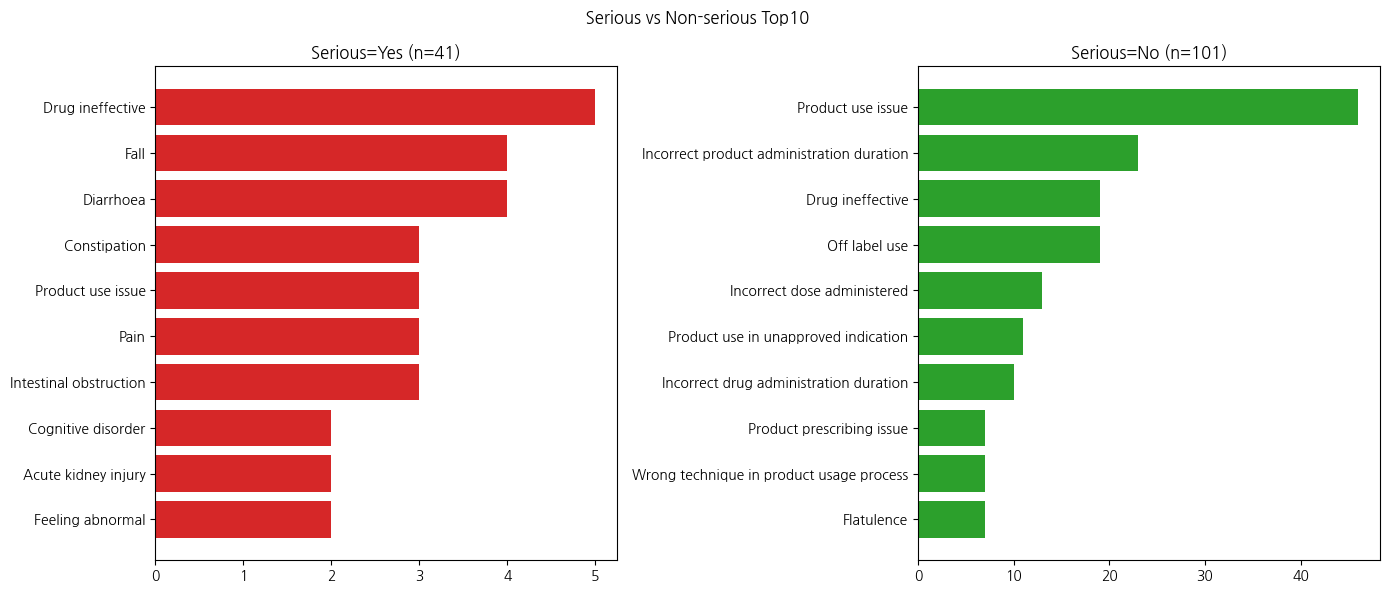

In [11]:
# Serious vs Non-serious Top10 비교
tmp2 = pd.DataFrame({'serious': lax['serious'].values, 'reaction_list': lax['reaction_list'].values})
ex2 = tmp2.explode('reaction_list').dropna(subset=['reaction_list'])
sc = ex2[ex2['serious'] == 'Yes']['reaction_list'].value_counts().head(10)
nsc = ex2[ex2['serious'] == 'No']['reaction_list'].value_counts().head(10)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(sc.index[::-1], sc.values[::-1], color='#d62728')
axes[0].set_title(f'Serious=Yes (n={(lax["serious"]=="Yes").sum()})')
axes[1].barh(nsc.index[::-1], nsc.values[::-1], color='#2ca02c')
axes[1].set_title(f'Serious=No (n={(lax["serious"]=="No").sum()})')
plt.suptitle(' Serious vs Non-serious Top10')
plt.tight_layout()
plt.show()

Non-severe: n=117, median=3.0, mean=6.1
Severe:     n=25, median=12.0, mean=48.9
Mann-Whitney U = 521.5, p-value = 3.877e-07


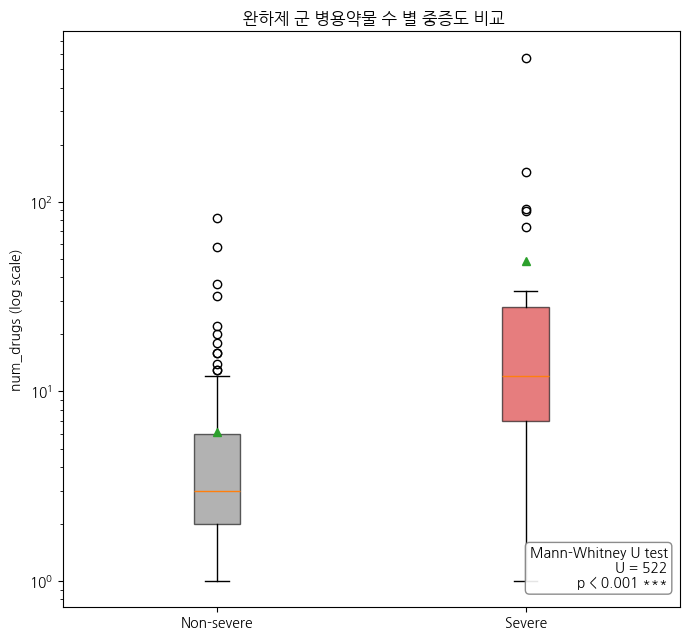

In [12]:
# 병용약물 수(num_drugs) 별 중증도 비교 - Mann-Whitney U
non_severe = lax.loc[~lax['any_severe'], 'num_drugs']
severe = lax.loc[lax['any_severe'], 'num_drugs']

u_stat, p_value = stats.mannwhitneyu(non_severe, severe, alternative='two-sided')
print(f"Non-severe: n={len(non_severe)}, median={non_severe.median():.1f}, mean={non_severe.mean():.1f}")
print(f"Severe:     n={len(severe)}, median={severe.median():.1f}, mean={severe.mean():.1f}")
print(f"Mann-Whitney U = {u_stat:.1f}, p-value = {p_value:.4g}")

fig, ax = plt.subplots(figsize=(7, 6.5))
bp = ax.boxplot([non_severe, severe], tick_labels=['Non-severe', 'Severe'], showmeans=True, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#7f7f7f', '#d62728']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_yscale('log')
ax.set_ylabel('num_drugs (log scale)')
ax.set_title(' 완하제 군 병용약물 수 별 중증도 비교')

p_str = 'p < 0.001' if p_value < 0.001 else f'p = {p_value:.4f}'
sig = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'n.s.'))
textstr = f'Mann-Whitney U test\nU = {u_stat:.0f}\n{p_str} {sig}'
ax.text(0.98, 0.03, textstr, transform=ax.transAxes, fontsize=10,
        ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9))
plt.tight_layout()
plt.show()

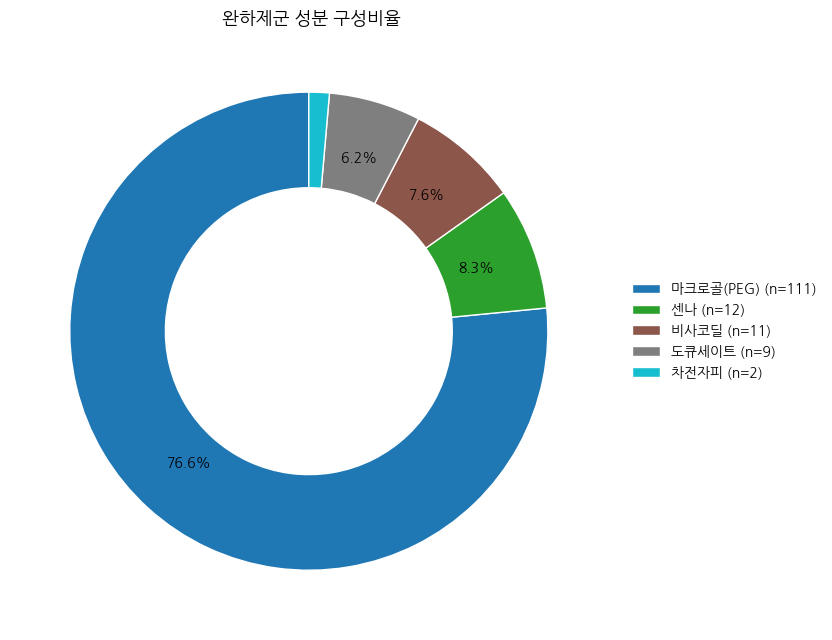

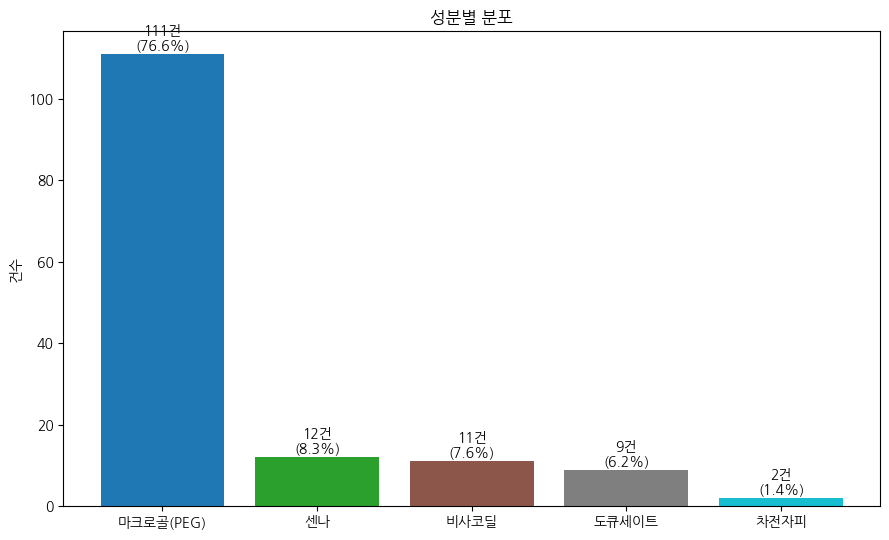

In [13]:
# 성분 구성비율 - 파이차트 & 막대그래프
counts = {}
for name, keys in ingredients.items():
    m = pd.Series(False, index=df.index)
    for k in keys:
        m = m | sd.str.contains(k, na=False)
    counts[name] = (m & ~not_laxative_mask).sum()
counts_s = pd.Series(counts).sort_values(ascending=False)
total = counts_s.sum()

fig, ax = plt.subplots(figsize=(8, 6.5))
colors = plt.cm.tab10(np.linspace(0, 1, len(counts_s)))
wedges, texts, autotexts = ax.pie(
    counts_s.values, autopct=lambda p: f'{p:.1f}%' if p >= 2 else '',
    startangle=90, colors=colors, pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=1),
)
legend_labels = [f'{name} (n={v})' for name, v in counts_s.items()]
ax.legend(wedges, legend_labels, loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10, frameon=False)
ax.set_title(f' 완하제군 성분 구성비율', fontsize=13)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.5))
c = plt.cm.tab10(np.linspace(0, 1, len(counts_s)))
bars = ax.bar(counts_s.index, counts_s.values, color=c)
for bar, v in zip(bars, counts_s.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, f'{v}건\n({v/total*100:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel('건수'); ax.set_title(f'성분별 분포')
plt.tight_layout()
plt.show()

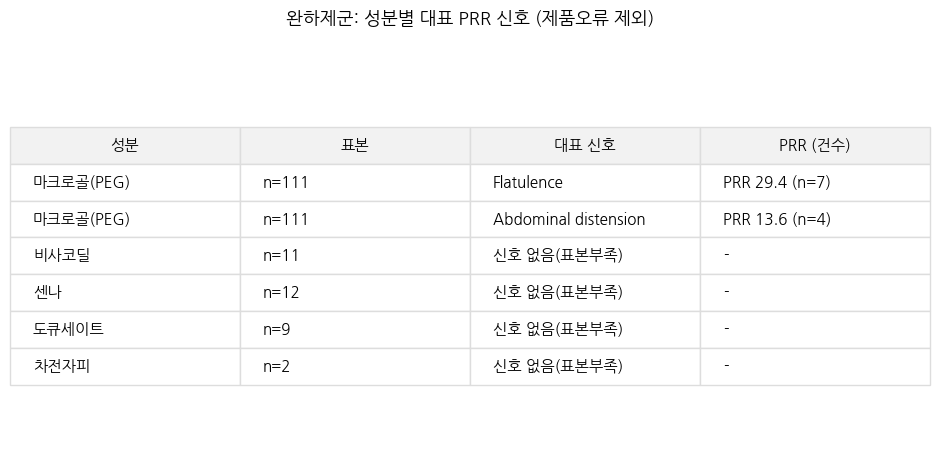

In [14]:
# 성분별 대표 PRR 신호 (제품오류 제외)
rows = []
for name, keys in ingredients.items():
    m = pd.Series(False, index=df.index)
    for k in keys:
        m = m | sd.str.contains(k, na=False)
    m_corrected = m & (~not_laxative_mask)
    n = m_corrected.sum()
    res = calc_prr_ror(m_corrected, df)
    res_clinical = res[~res['reaction'].isin(med_err_terms)]
    target = res_clinical if len(res_clinical) > 0 else res
    if len(target) == 0:
        rows.append([name, f'n={n}', '신호 없음(표본부족)', '-'])
        continue
    top2 = target.head(2)
    for _, r in top2.iterrows():
        rows.append([name, f'n={n}', r['reaction'], f"PRR {r['PRR']:.1f} (n={r['a']})"])

fig, ax = plt.subplots(figsize=(9.5, len(rows)*0.6 + 1.2))
ax.axis('off')
col_labels = ['성분', '표본', '대표 신호', 'PRR (건수)']
table = ax.table(cellText=rows, colLabels=col_labels, loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.0)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#dddddd')
    if r == 0:
        cell.set_text_props(weight='bold'); cell.set_facecolor('#f2f2f2')
    else:
        cell.set_facecolor('white')
plt.title('완하제군: 성분별 대표 PRR 신호 (제품오류 제외)', fontsize=13, pad=20)
plt.tight_layout()
plt.show()

전체 그룹 수: 193
Total>=5인 그룹 수: 18


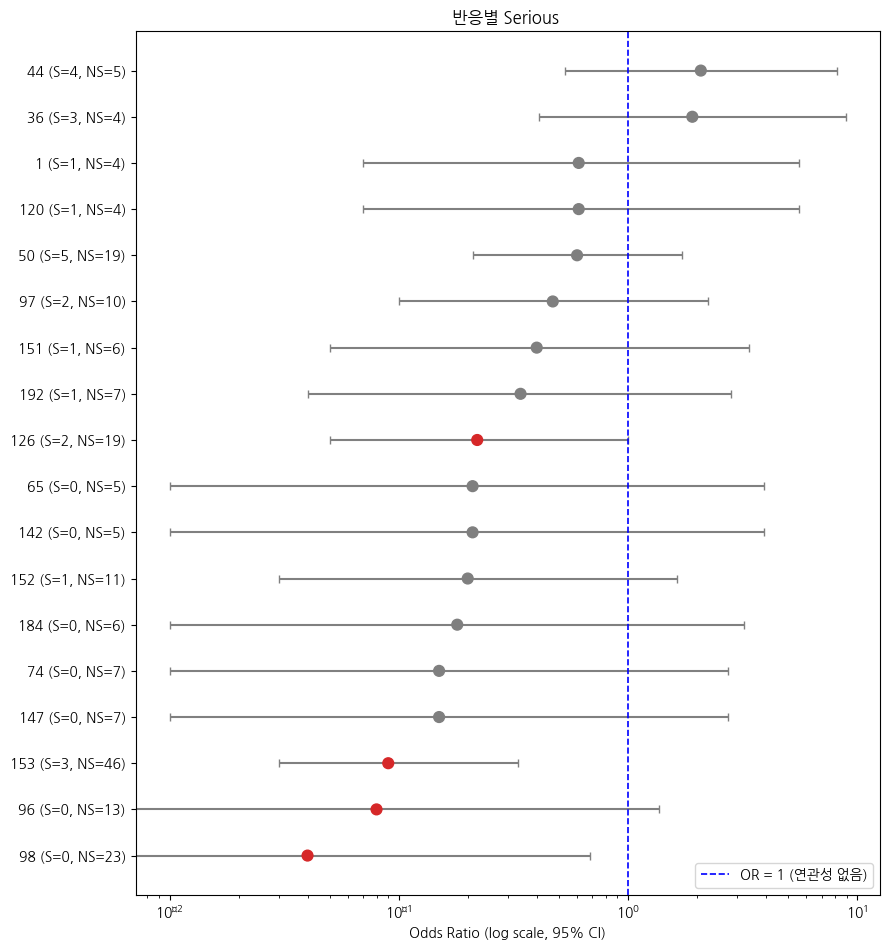

In [15]:
# 반응별 Serious 오즈비 (Forest plot, Total>=5)
ex = lax[['serious', 'reaction_list']].explode('reaction_list').dropna(subset=['reaction_list'])
grp = ex.groupby('reaction_list').agg(
    Total=('serious', 'count'),
    Serious=('serious', lambda x: (x == 'Yes').sum())
).reset_index()
print("전체 그룹 수:", len(grp))
print("Total>=5인 그룹 수:", (grp['Total'] >= 5).sum())

grp = grp[grp['Total'] >= 5].copy()
grp['NonSerious'] = grp['Total'] - grp['Serious']
total_serious = (lax['serious'] == 'Yes').sum()
total_nonserious = (lax['serious'] == 'No').sum()

rows = []
for reac, row in grp.iterrows():
    a = row['Serious']; b = row['NonSerious']
    c = total_serious - a; d = total_nonserious - b
    odds_fisher, p_value = stats.fisher_exact([[a, b], [c, d]])
    if min(a, b, c, d) == 0:
        a_, b_, c_, d_ = a+0.5, b+0.5, c+0.5, d+0.5
    else:
        a_, b_, c_, d_ = a, b, c, d
    OR = (a_*d_) / (b_*c_)
    se_log_or = np.sqrt(1/a_ + 1/b_ + 1/c_ + 1/d_)
    ci_low = np.exp(np.log(OR) - 1.96*se_log_or)
    ci_high = np.exp(np.log(OR) + 1.96*se_log_or)
    rows.append({'Reaction': reac, 'a(Serious)': a, 'b(NonSerious)': b,
                 'OR': round(OR, 2), 'CI_low': round(ci_low, 2), 'CI_high': round(ci_high, 2),
                 'p_value': round(p_value, 4)})

result = pd.DataFrame(rows).sort_values('OR', ascending=False)

fig, ax = plt.subplots(figsize=(9, len(result)*0.45 + 1.5))
y_pos = np.arange(len(result))[::-1]
colors = ['#d62728' if p < 0.05 else '#7f7f7f' for p in result['p_value']]
err_low = result['OR'] - result['CI_low']
err_high = result['CI_high'] - result['OR']
ax.errorbar(result['OR'], y_pos, xerr=[err_low, err_high], fmt='o', color='black', ecolor='gray', capsize=3, markersize=0)
ax.scatter(result['OR'], y_pos, c=colors, s=60, zorder=3)
ax.axvline(1, color='blue', linestyle='--', linewidth=1.2, label='OR = 1 (연관성 없음)')
ax.set_xscale('log')
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{r} (S={int(a)}, NS={int(b)})" for r, a, b in zip(result['Reaction'], result['a(Serious)'], result['b(NonSerious)'])])
ax.set_xlabel('Odds Ratio (log scale, 95% CI)')
ax.set_title('반응별 Serious ')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

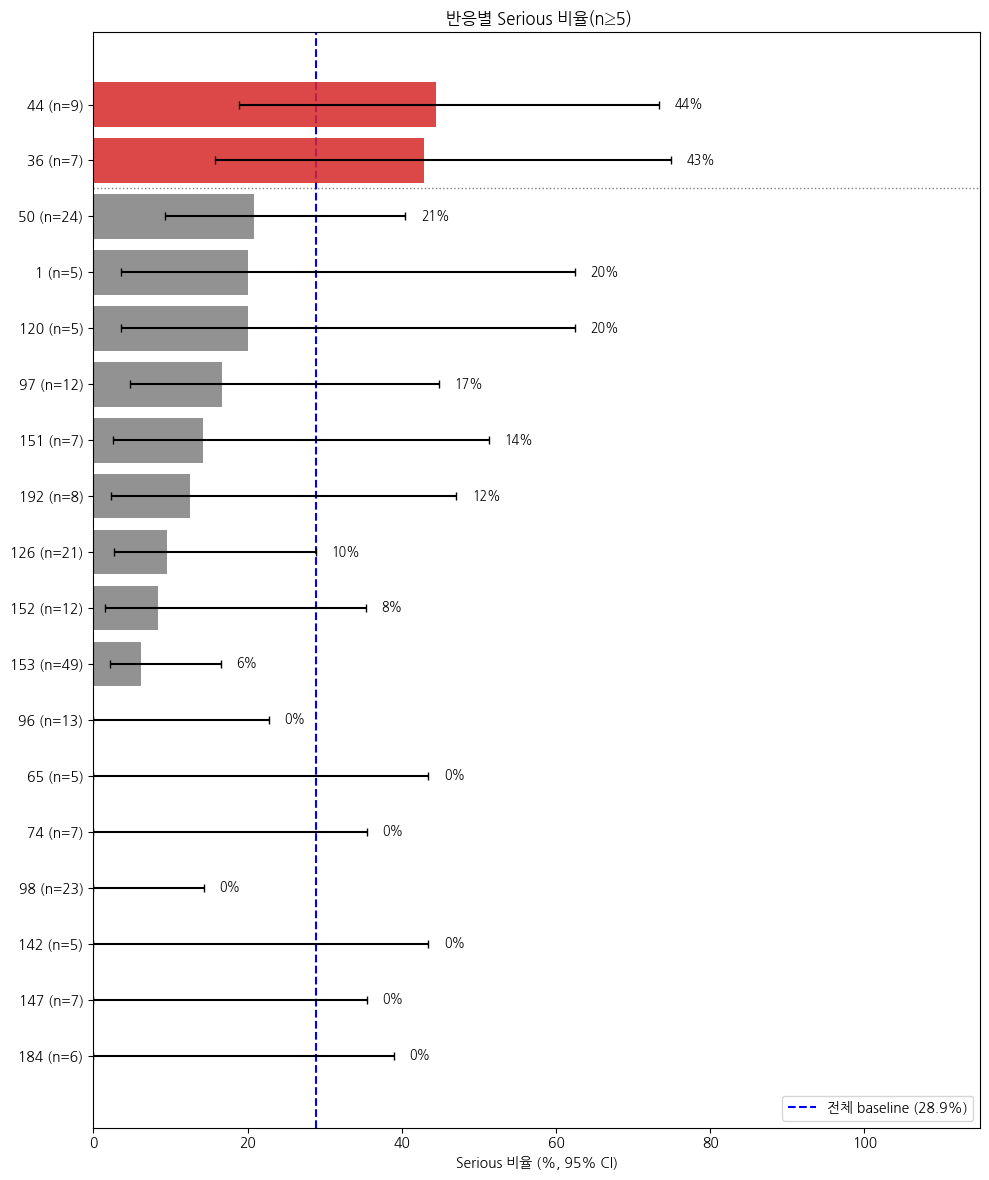

In [16]:
# 반응별 Serious 비율(n>=5) - baseline 대비 위/아래 구분
overall_serious_rate = (lax['serious'] == 'Yes').mean()
baseline_pct = overall_serious_rate * 100

grp['Serious_pct'] = grp['Serious'] / grp['Total'] * 100
ci_low_list, ci_high_list = [], []
for _, row in grp.iterrows():
    n = row['Total']; phat = row['Serious'] / n; z = 1.96
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2*n)) / denom
    half = (z * np.sqrt(phat*(1-phat)/n + z**2/(4*n**2))) / denom
    ci_low_list.append(max(0, center - half) * 100)
    ci_high_list.append(min(1, center + half) * 100)
grp['CI_low'] = ci_low_list; grp['CI_high'] = ci_high_list

above = grp[grp['Serious_pct'] > baseline_pct].sort_values('Serious_pct', ascending=False)
below = grp[grp['Serious_pct'] <= baseline_pct].sort_values('Serious_pct', ascending=False)
grp_ordered = pd.concat([above, below])

contingency = grp[['Serious', 'NonSerious']].values
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

n_total = len(grp_ordered)
fig, ax = plt.subplots(figsize=(10, n_total*0.55 + 2))
y_pos = np.arange(n_total)[::-1]

colors = ['#d62728' if pct > baseline_pct else '#7f7f7f' for pct in grp_ordered['Serious_pct']]
err_low = grp_ordered['Serious_pct'] - grp_ordered['CI_low']
err_high = grp_ordered['CI_high'] - grp_ordered['Serious_pct']

ax.barh(y_pos, grp_ordered['Serious_pct'], color=colors, xerr=[err_low, err_high],
        capsize=3, ecolor='black', alpha=0.85)
ax.axvline(baseline_pct, color='blue', linestyle='--', linewidth=1.5,
           label=f'전체 baseline ({baseline_pct:.1f}%)', zorder=0)

if len(above) > 0 and len(below) > 0:
    boundary_y = y_pos[len(above)-1] - 0.5
    ax.axhline(boundary_y, color='black', linestyle=':', linewidth=1, alpha=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"{r} (n={int(t)})" for r, t in zip(grp_ordered.index, grp_ordered['Total'])])
ax.set_xlabel('Serious 비율 (%, 95% CI)')
ax.set_xlim(0, 115)
ax.set_title(f' 반응별 Serious 비율(n≥5)')
ax.legend(loc='lower right')
for i, (pct, y) in enumerate(zip(grp_ordered['Serious_pct'], y_pos)):
    ax.text(grp_ordered['CI_high'].iloc[i] + 2, y, f'{pct:.0f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

U statistic : 1654625.50
p-value : 4.1642e-09


/tmp/ipykernel_837/471499901.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_837/471499901.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Non-laxative','Laxative'])


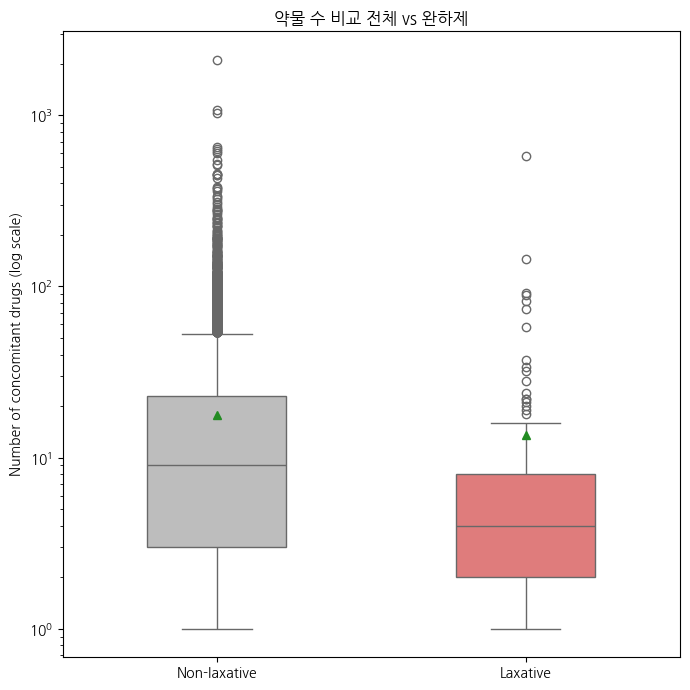

U = 1,654,626
p = 4.164e-09


In [17]:
# 완하제 여부 컬럼 생성 및 병용약물 수(num_drugs) 비교 (전체 df 기준)
df['laxative'] = 0
df.loc[corrected_mask, 'laxative'] = 1

lax_numdrugs = df[df['laxative']==1]['num_drugs']
non_numdrugs = df[df['laxative']==0]['num_drugs']

u_stat, p_value = mannwhitneyu(non_numdrugs, lax_numdrugs, alternative='two-sided')
print(f'U statistic : {u_stat:.2f}')
print(f'p-value : {p_value:.4e}')

fig, ax = plt.subplots(figsize=(7,7))
ax = sns.boxplot(
    data=df, x='laxative', y='num_drugs', width=0.45,
    palette=['#bdbdbd', '#ef6c6c'], showmeans=True,
    meanprops={'marker':'^', 'markerfacecolor':'forestgreen', 'markeredgecolor':'forestgreen', 'markersize':6}
)
ax.set_yscale('log')
ax.set_xticklabels(['Non-laxative','Laxative'])
ax.set_xlabel('')
ax.set_ylabel('Number of concomitant drugs (log scale)')
ax.set_title('약물 수 비교 전체 vs 완하제')
plt.tight_layout()
plt.show()

text = f"U = {u_stat:,.0f}\np = {p_value:.3e}"
print(text)

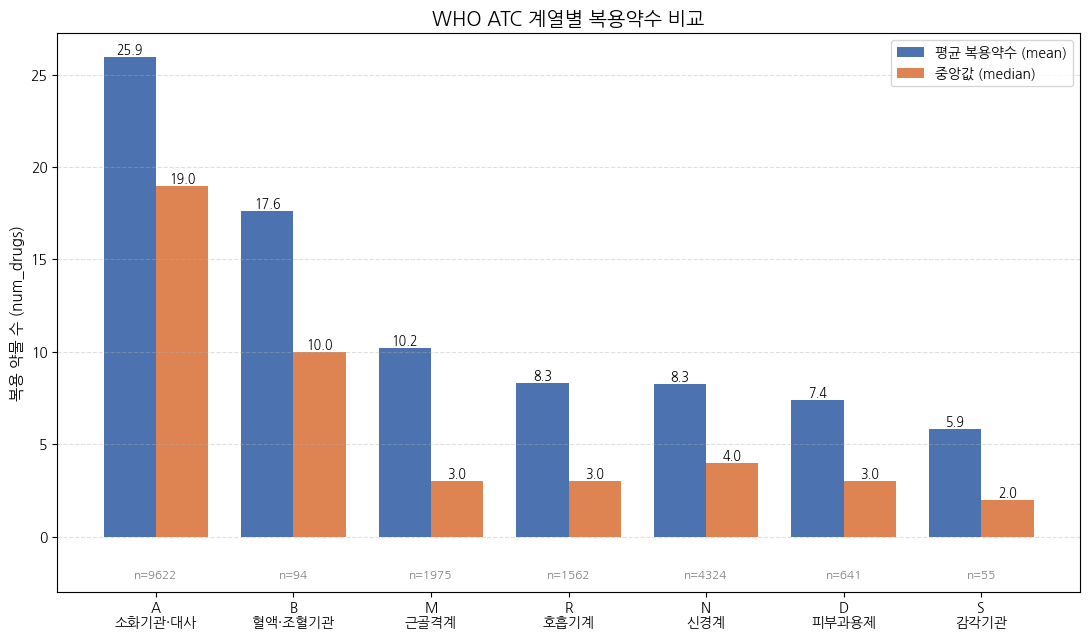

In [18]:
# WHO ATC 계열별 복용약수(num_drugs) 비교
atc_names = {
    'A': 'A\n소화기관·대사', 'B': 'B\n혈액·조혈기관', 'D': 'D\n피부과용제',
    'M': 'M\n근골격계', 'N': 'N\n신경계', 'R': 'R\n호흡기계', 'S': 'S\n감각기관',
}
g = df.groupby('WHO_ATC')['num_drugs'].agg(['count', 'mean', 'median']).reset_index()
g = g.sort_values('mean', ascending=False)
g['label'] = g['WHO_ATC'].map(atc_names)

fig, ax = plt.subplots(figsize=(11, 6.5))
x = range(len(g)); width = 0.38
b1 = ax.bar([i - width / 2 for i in x], g['mean'], width, label='평균 복용약수 (mean)', color='#4C72B0')
b2 = ax.bar([i + width / 2 for i in x], g['median'], width, label='중앙값 (median)', color='#DD8452')

ax.set_xticks(list(x)); ax.set_xticklabels(g['label'], fontsize=10)
ax.set_ylabel('복용 약물 수 (num_drugs)', fontsize=11)
ax.set_title('WHO ATC 계열별 복용약수 비교', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.4)

for rects in (b1, b2):
    for r in rects:
        h = r.get_height()
        ax.annotate(f'{h:.1f}', (r.get_x() + r.get_width() / 2, h), ha='center', va='bottom', fontsize=9)
for i, n in enumerate(g['count']):
    ax.annotate(f'n={n}', (i, -1.8), ha='center', va='top', fontsize=8.5, color='gray')

ax.set_ylim(bottom=-3)
plt.tight_layout()
plt.show()

A계열(완하제 제외): 9480건 / 완하제: 142건


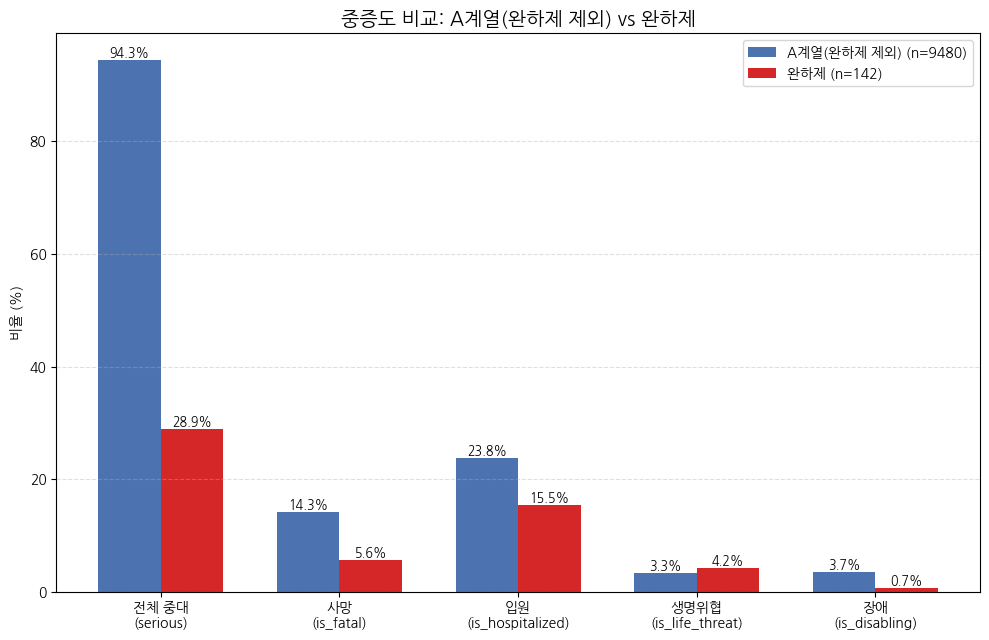


[중증도 카이제곱 검정]
  사망
(is_fatal): A=14.3%, Lax=5.6%, chi2 p=0.004902
  입원
(is_hospitalized): A=23.8%, Lax=15.5%, chi2 p=0.02666
  생명위협
(is_life_threat): A=3.3%, Lax=4.2%, chi2 p=0.7307
  장애
(is_disabling): A=3.7%, Lax=0.7%, chi2 p=0.09969

[복약수 비교] A: mean=26.1, median=19.0 / 완하제: mean=13.6, median=4.0
Mann-Whitney U = 1065182.5, p = 7.573e-33


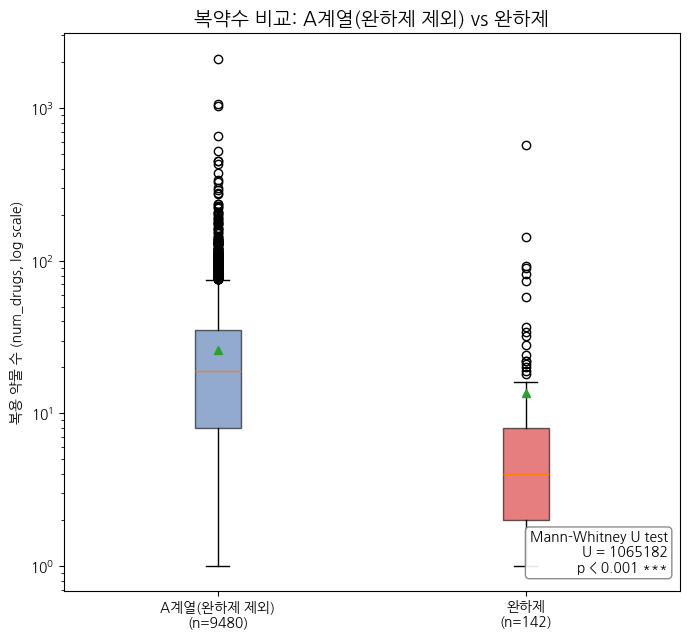

In [19]:
# A계열(완하제 제외) vs 완하제: 중증도 및 복약수 비교
a_only_mask = (df['WHO_ATC'] == 'A') & (~lax_mask)
grp_a = df[a_only_mask]
grp_lax = df[lax_mask]
n_a, n_lax = len(grp_a), len(grp_lax)
print(f"A계열(완하제 제외): {n_a}건 / 완하제: {n_lax}건")

sev_labels = ['사망\n(is_fatal)', '입원\n(is_hospitalized)', '생명위협\n(is_life_threat)', '장애\n(is_disabling)']
sev_a = [grp_a[c].mean() * 100 for c in sev_cols]
sev_lax = [grp_lax[c].mean() * 100 for c in sev_cols]

serious_a = (grp_a['serious'] == 'Yes').mean() * 100
serious_lax = (grp_lax['serious'] == 'Yes').mean() * 100
sev_labels_full = ['전체 중대\n(serious)'] + sev_labels
sev_a_full = [serious_a] + sev_a
sev_lax_full = [serious_lax] + sev_lax

x = np.arange(len(sev_labels_full)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 6.5))
b1 = ax.bar(x - w/2, sev_a_full, w, label=f'A계열(완하제 제외) (n={n_a})', color='#4C72B0')
b2 = ax.bar(x + w/2, sev_lax_full, w, label=f'완하제 (n={n_lax})', color='#d62728')
for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}%', (bar.get_x() + bar.get_width()/2, h), ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(sev_labels_full, fontsize=10)
ax.set_ylabel('비율 (%)')
ax.set_title('중증도 비교: A계열(완하제 제외) vs 완하제', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("\n[중증도 카이제곱 검정]")
for c, lbl in zip(sev_cols, sev_labels):
    ct = pd.DataFrame({
        'A': [grp_a[c].sum(), n_a - grp_a[c].sum()],
        'Lax': [grp_lax[c].sum(), n_lax - grp_lax[c].sum()]
    }, index=['True', 'False'])
    chi2, p, dof, exp = chi2_contingency(ct)
    pct_a = grp_a[c].mean() * 100
    pct_lax = grp_lax[c].mean() * 100
    print(f"  {lbl}: A={pct_a:.1f}%, Lax={pct_lax:.1f}%, chi2 p={p:.4g}")

nd_a = grp_a['num_drugs']
nd_lax = grp_lax['num_drugs']
u_stat, p_value = mannwhitneyu(nd_a, nd_lax, alternative='two-sided')
print(f"\n[복약수 비교] A: mean={nd_a.mean():.1f}, median={nd_a.median():.1f} / 완하제: mean={nd_lax.mean():.1f}, median={nd_lax.median():.1f}")
print(f"Mann-Whitney U = {u_stat:.1f}, p = {p_value:.4g}")

fig, ax = plt.subplots(figsize=(7, 6.5))
bp = ax.boxplot([nd_a, nd_lax], tick_labels=[f'A계열(완하제 제외)\n(n={n_a})', f'완하제\n(n={n_lax})'],
                showmeans=True, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#4C72B0', '#d62728']):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_yscale('log')
ax.set_ylabel('복용 약물 수 (num_drugs, log scale)')
ax.set_title('복약수 비교: A계열(완하제 제외) vs 완하제', fontsize=14, fontweight='bold')

p_str = 'p < 0.001' if p_value < 0.001 else f'p = {p_value:.4f}'
sig = '***' if p_value < 0.001 else ('**' if p_value < 0.01 else ('*' if p_value < 0.05 else 'n.s.'))
textstr = f'Mann-Whitney U test\nU = {u_stat:.0f}\n{p_str} {sig}'
ax.text(0.98, 0.03, textstr, transform=ax.transAxes, fontsize=10,
        ha='right', va='bottom', bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9))
plt.tight_layout()
plt.show()

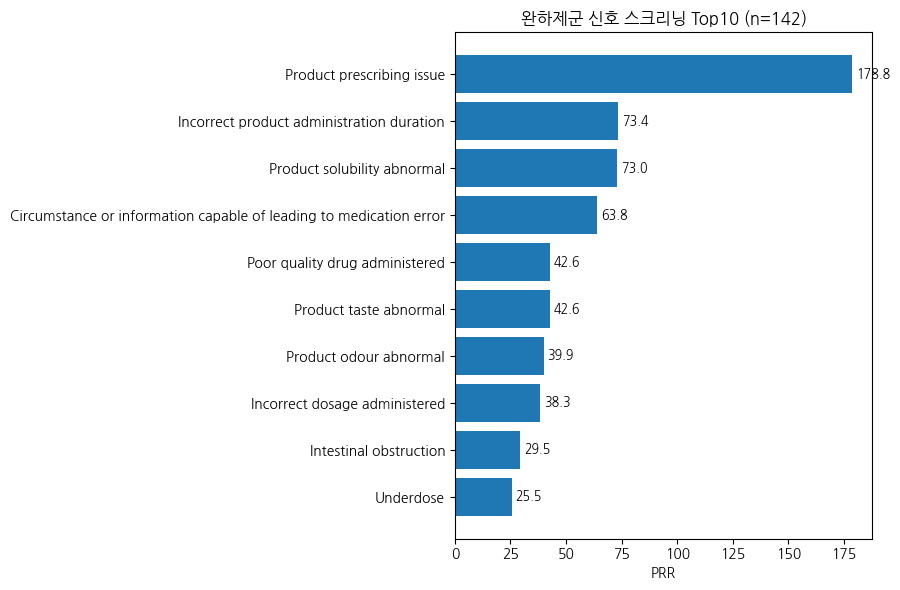

In [20]:
# 신호 스크리닝 Top10 (medication error 포함 전체)
top10 = res_all.head(10)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top10['reaction'][::-1], top10['PRR'][::-1], color='#1f77b4')
for i, v in enumerate(top10['PRR'][::-1]):
    ax.text(v + max(top10['PRR'])*0.01, i, f'{v:.1f}', va='center', fontsize=9)
ax.set_xlabel('PRR')
ax.set_title(f'완하제군 신호 스크리닝 Top10 (n={n_drug})')
plt.tight_layout()
plt.show()


연령대별 반응 비율(%):
age_group               Middle-Aged(41-65)  Senior(66-80)  Elderly(81+)
reaction                                                               
Intestinal obstruction                 0.0            2.2           2.9
Flatulence                             4.5            4.4           8.8
Constipation                           0.0           11.1           0.0
Abdominal distension                   0.0            2.2           5.9
Muscle spasms                          0.0            4.4           0.0
Diarrhoea                             13.6            6.7           5.9


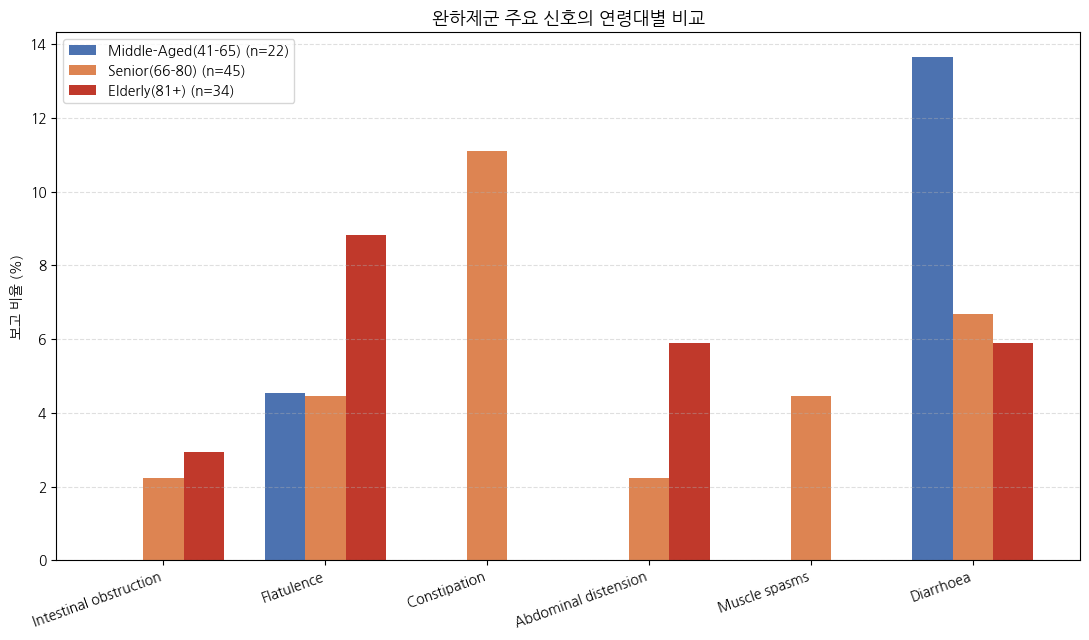

In [21]:
# 완하제군 주요 신호의 연령대별 비교
key_reactions = ['Intestinal obstruction', 'Flatulence', 'Constipation', 'Abdominal distension',
                  'Muscle spasms', 'Diarrhoea']

for r in key_reactions:
    lax[f'has_{r}'] = lax['reaction_list'].apply(lambda l: r in l)

age_groups = ['Middle-Aged(41-65)', 'Senior(66-80)', 'Elderly(81+)']
n_by_age = lax['age_group'].value_counts()

rows = []
for ag in age_groups:
    sub = lax[lax['age_group'] == ag]
    n = len(sub)
    for r in key_reactions:
        pct = sub[f'has_{r}'].mean() * 100
        rows.append({'age_group': ag, 'reaction': r, 'pct': pct, 'n': n})

result = pd.DataFrame(rows)
pivot = result.pivot(index='reaction', columns='age_group', values='pct').reindex(index=key_reactions, columns=age_groups)
print("\n연령대별 반응 비율(%):")
print(pivot.round(1))

x = np.arange(len(key_reactions))
width = 0.25
fig, ax = plt.subplots(figsize=(11, 6.5))
colors = ['#4C72B0', '#DD8452', '#c0392b']
for i, ag in enumerate(age_groups):
    vals = pivot[ag].values
    ax.bar(x + (i-1)*width, vals, width, label=f'{ag} (n={n_by_age.get(ag,0)})', color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(key_reactions, rotation=20, ha='right')
ax.set_ylabel('보고 비율 (%)')
ax.set_title('완하제군 주요 신호의 연령대별 비교', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()